# 🌸 Iris Flower Classification
## CodeAlpha Data Science Internship — Task 1

**Workflow:** Load → Clean → Explore → Preprocess → Train → Evaluate → Compare

## Step 1: Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported!")

All libraries imported!


## Step 2: Load the Dataset

In [17]:
df = pd.read_csv("Iris.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Shape: (150, 6)
Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


## Step 3: Clean the Dataset

In [18]:
# Drop Id column — not a feature
df.drop(columns=["Id"], inplace=True)

# Check duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df.drop_duplicates(inplace=True)

# Check missing values
print(f"\nMissing values:\n{df.isnull().sum()}")
df.dropna(inplace=True)

# Data types
print(f"\nData types:\n{df.dtypes}")
print(f"\nClass Distribution:\n{df['Species'].value_counts()}")
print(f"\n Clean dataset shape: {df.shape}")

Duplicate rows: 3

Missing values:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Data types:
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Class Distribution:
Species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

 Clean dataset shape: (147, 5)


## Step 4: Exploratory Data Analysis

### 4a. Summary Statistics

In [19]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### 4b. Feature Distributions

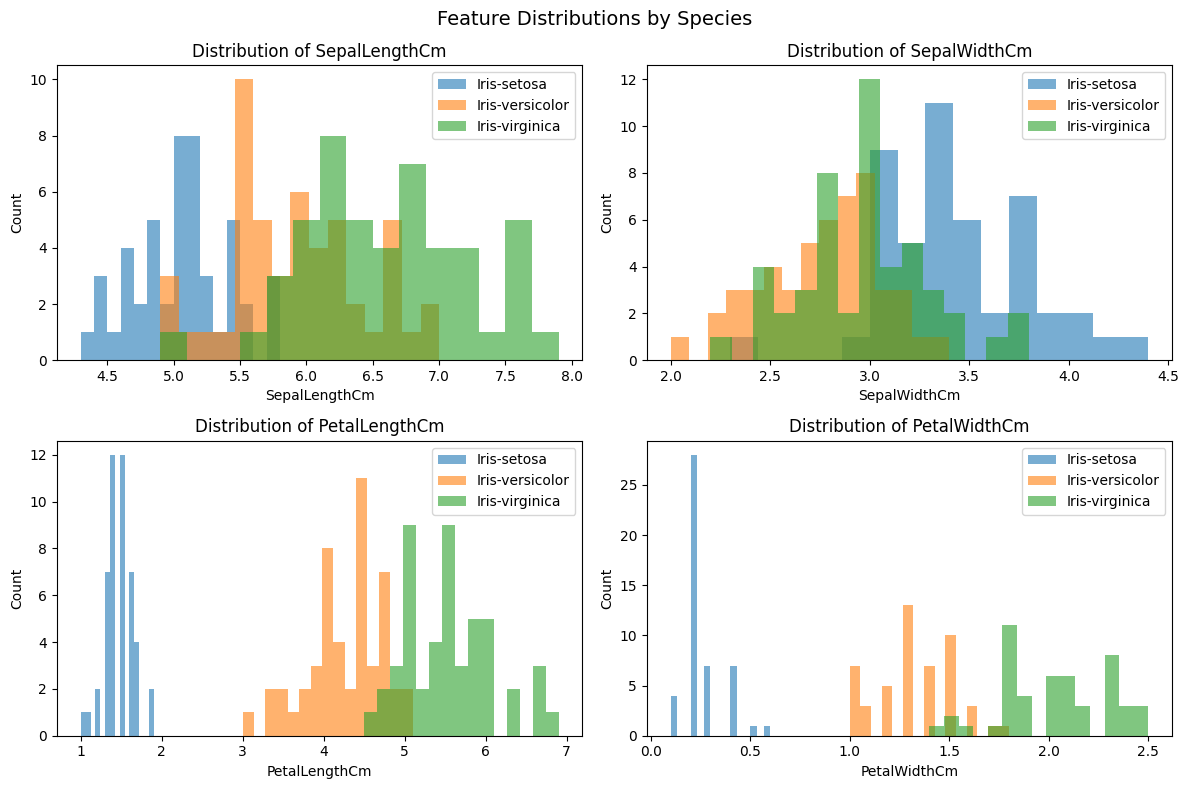

Saved: iris_distributions.png


In [20]:
features = df.columns[:-1]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    for species, group in df.groupby("Species"):
        ax.hist(group[feat], alpha=0.6, label=species, bins=15)
    ax.set_title(f"Distribution of {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend()
plt.suptitle("Feature Distributions by Species", fontsize=14)
plt.tight_layout()
plt.savefig("iris_distributions.png", dpi=150)
plt.show()
print("Saved: iris_distributions.png")

### 4c. Boxplots

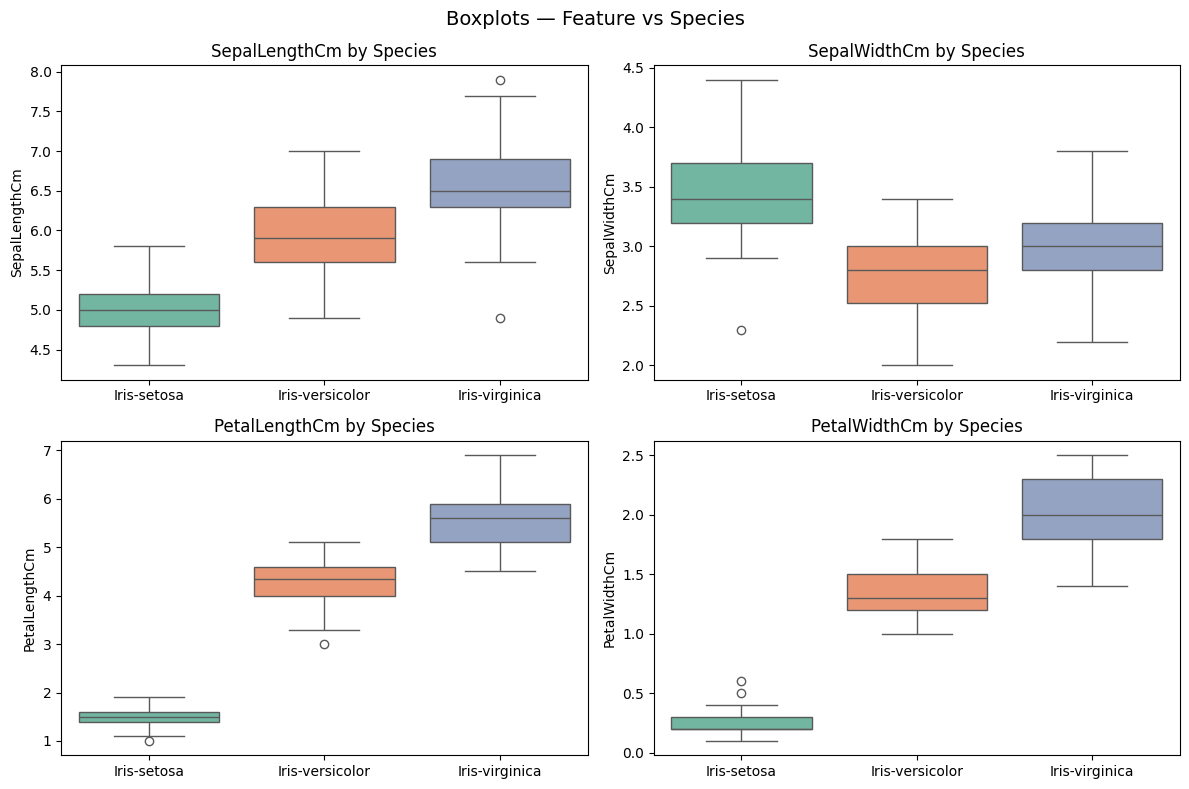

Saved: iris_boxplots.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Species", y=feat, palette="Set2", ax=ax)
    ax.set_title(f"{feat} by Species")
    ax.set_xlabel("")
plt.suptitle("Boxplots — Feature vs Species", fontsize=14)
plt.tight_layout()
plt.savefig("iris_boxplots.png", dpi=150)
plt.show()
print("Saved: iris_boxplots.png")

### 4d. Correlation Heatmap

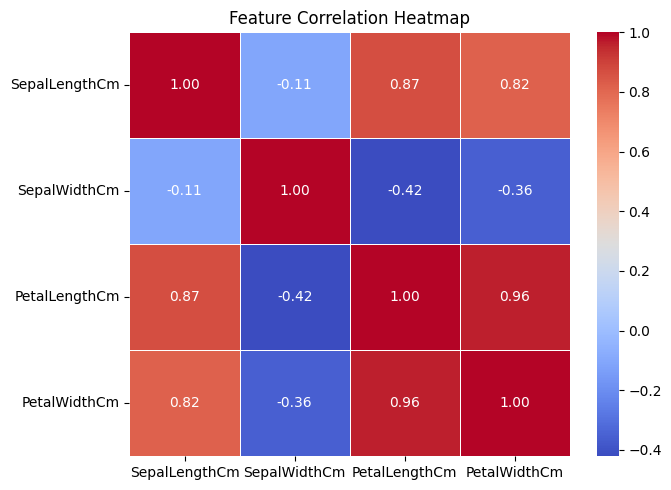

Saved: iris_heatmap.png


In [22]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("iris_heatmap.png", dpi=150)
plt.show()
print("Saved: iris_heatmap.png")

### 4e. Pairplot

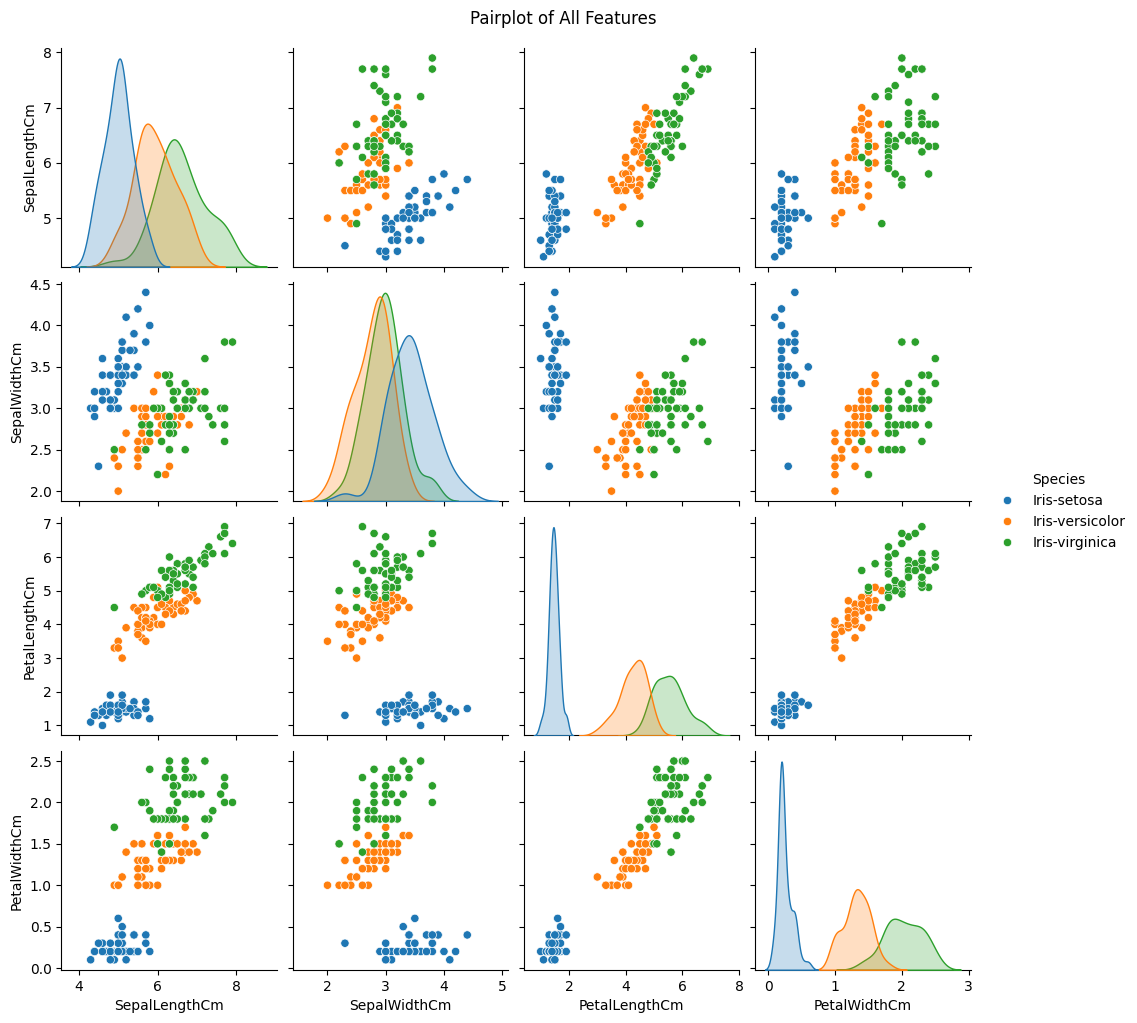

Saved: iris_pairplot.png


In [23]:
pair = sns.pairplot(df, hue="Species", diag_kind="kde", height=2.5)
pair.fig.suptitle("Pairplot of All Features", y=1.02)
plt.savefig("iris_pairplot.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: iris_pairplot.png")

## Step 5: Preprocess

In [24]:
X = df.drop(columns=["Species"])
y = df["Species"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTrain samples : {X_train.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")
print("\n Preprocessing done!")

Label encoding: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}

Train samples : 117
Test  samples : 30

 Preprocessing done!


## Step 6: Train Models

In [26]:
models = {
    "K-Nearest Neighbors"    : KNeighborsClassifier(n_neighbors=5),
    "Decision Tree"          : DecisionTreeClassifier(random_state=42),
    "Random Forest"          : RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine" : SVC(kernel="rbf", random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"y_pred": y_pred, "accuracy": acc}
    print(f" {name} - Accuracy: {acc*100:.2f}%")

 K-Nearest Neighbors - Accuracy: 100.00%
 Decision Tree - Accuracy: 93.33%
 Random Forest - Accuracy: 96.67%
 Support Vector Machine - Accuracy: 93.33%


## Step 7: Evaluate Each Model

In [27]:
for name, res in results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, res["y_pred"], target_names=le.classes_))


  K-Nearest Neighbors
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


  Decision Tree
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


  Random Forest
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.

## Step 8: Compare All Models

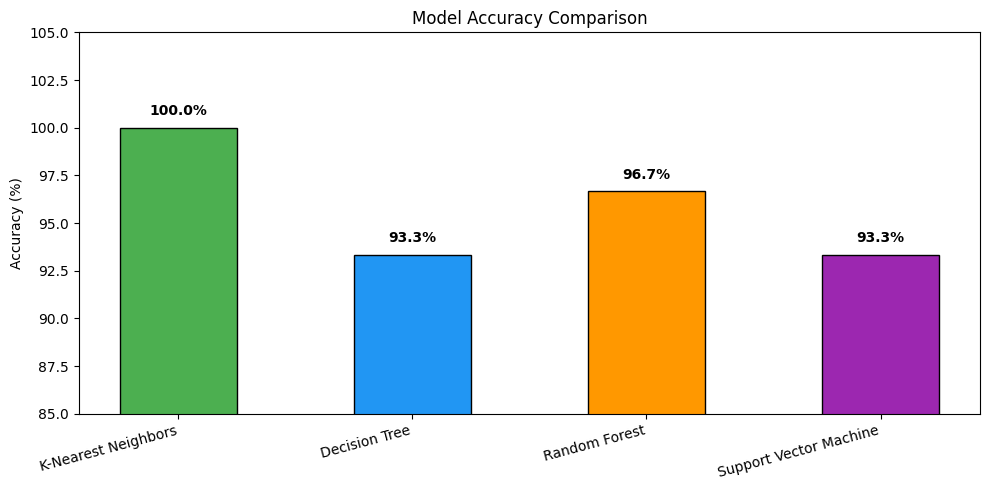

Saved: iris_model_comparison.png


In [28]:
names = list(results.keys())
accuracies = [results[n]["accuracy"] * 100 for n in names]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, accuracies,
               color=["#4CAF50","#2196F3","#FF9800","#9C27B0"],
               edgecolor="black", width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5, f"{acc:.1f}%",
             ha="center", va="bottom", fontweight="bold")
plt.ylim(85, 105)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("iris_model_comparison.png", dpi=150)
plt.show()
print("Saved: iris_model_comparison.png")

## Step 9: Confusion Matrices

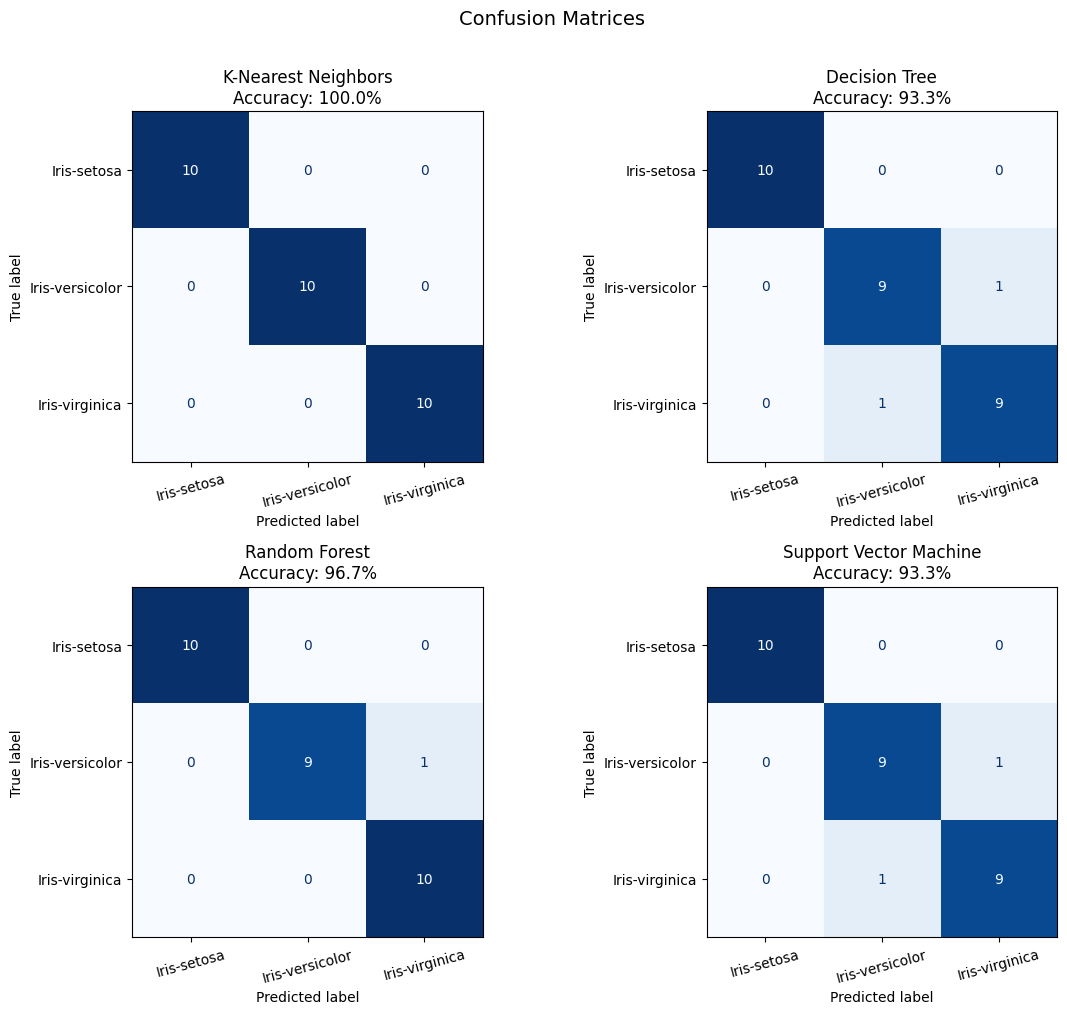

Saved: iris_confusion_matrices.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']*100:.1f}%")
    ax.set_xticklabels(le.classes_, rotation=15)
plt.suptitle("Confusion Matrices", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("iris_confusion_matrices.png", dpi=150)
plt.show()
print("Saved: iris_confusion_matrices.png")

## Step 10: Final Summary

In [30]:
best_name = max(results, key=lambda n: results[n]["accuracy"])
best_acc  = results[best_name]["accuracy"]

print("=" * 50)
print("  FINAL MODEL ACCURACY SUMMARY")
print("=" * 50)
for name in names:
    acc  = results[name]["accuracy"]
    star = "  BEST" if name == best_name else ""
    print(f"  {name:<30} {acc*100:.2f}%{star}")
print(f"\n Best Model : {best_name}")
print(f"   Accuracy   : {best_acc*100:.2f}%")
print("\n Project Complete!")

  FINAL MODEL ACCURACY SUMMARY
  K-Nearest Neighbors            100.00%  BEST
  Decision Tree                  93.33%
  Random Forest                  96.67%
  Support Vector Machine         93.33%

 Best Model : K-Nearest Neighbors
   Accuracy   : 100.00%

 Project Complete!


## Conclusion
- **Petal Length and Petal Width** are the most important features
- **Iris-setosa** is perfectly separable from the other two species
- **KNN** achieved the highest accuracy on this dataset
- All models performed well (≥90%)

---
CodeAlpha Data Science Internship - Task 1 | Iris Flower Classification